In [42]:
import pandas as pd

In [43]:
df = pd.read_csv('Iris.csv')

In [44]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [45]:
df = df.iloc[:,1:]

In [46]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [47]:
from sklearn.preprocessing import LabelEncoder

In [48]:
encoder = LabelEncoder()

In [49]:
df['Species'] = encoder.fit_transform(df['Species'])

In [50]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [51]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [52]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

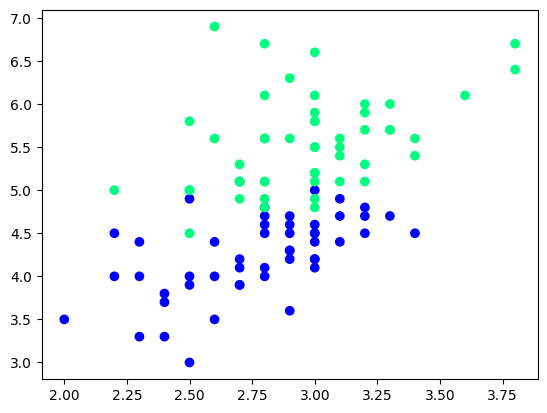

In [54]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [55]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
89,2.5,4.0,1
101,2.7,5.1,2
63,2.9,4.7,1
88,3.0,4.1,1
94,2.7,4.2,1
61,3.0,4.2,1
73,2.8,4.7,1
50,3.2,4.7,1
77,3.0,5.0,1
98,2.5,3.0,1


In [56]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [57]:
df_train

,SepalWidthCm,PetalLengthCm,Species
93,2.3,3.3,1
116,3.0,5.5,2
67,2.7,4.1,1
65,3.1,4.4,1
76,2.8,4.8,1
104,3.0,5.8,2
144,3.3,5.7,2
137,3.1,5.5,2
148,3.4,5.4,2
57,2.4,3.3,1


In [58]:
df_val

,SepalWidthCm,PetalLengthCm,Species
51,3.2,4.5,1
140,3.1,5.6,2
66,3.0,4.5,1
72,2.5,4.9,1
114,2.8,5.1,2


In [59]:
df_test

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
91,3.0,4.6,1
77,3.0,5.0,1
62,2.2,4.0,1
145,3.0,5.2,2


In [60]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [61]:
y_test

array([1, 2, 1, 1, 2])

# Case 1 - Bagging

In [62]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
65,3.1,4.4,1
104,3.0,5.8,2
65,3.1,4.4,1
93,2.3,3.3,1
104,3.0,5.8,2
148,3.4,5.4,2
67,2.7,4.1,1
67,2.7,4.1,1


In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [71]:
dt_bag1 = DecisionTreeClassifier()

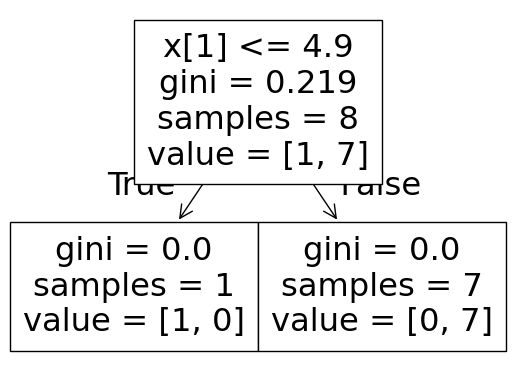

1.0


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


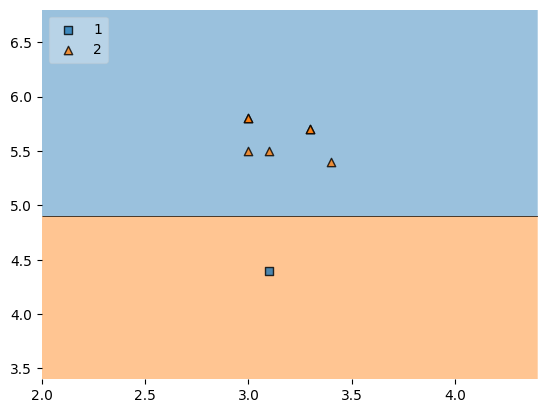

In [72]:
evaluate(dt_bag1,X,y)

In [73]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
67,2.7,4.1,1
93,2.3,3.3,1
116,3.0,5.5,2
67,2.7,4.1,1
67,2.7,4.1,1
93,2.3,3.3,1
67,2.7,4.1,1
148,3.4,5.4,2


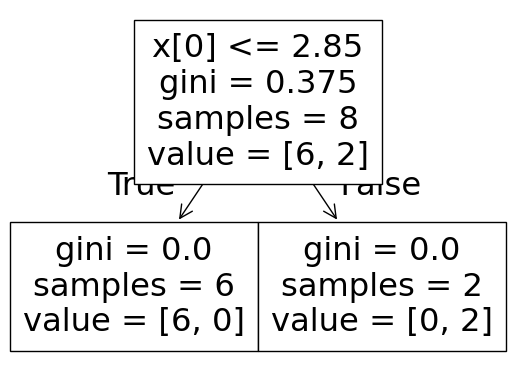

0.4


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


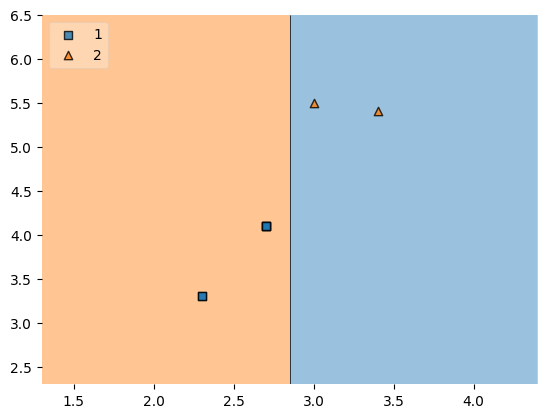

In [74]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [75]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
144,3.3,5.7,2
104,3.0,5.8,2
67,2.7,4.1,1
116,3.0,5.5,2
137,3.1,5.5,2
104,3.0,5.8,2
57,2.4,3.3,1
93,2.3,3.3,1


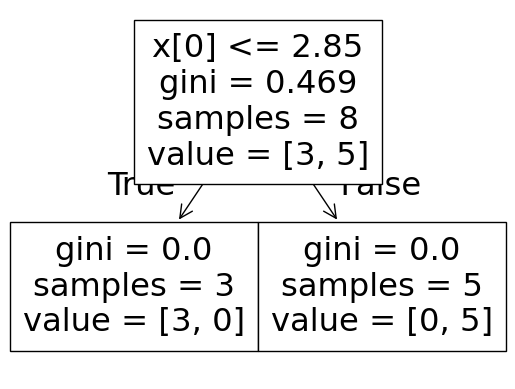

0.4


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


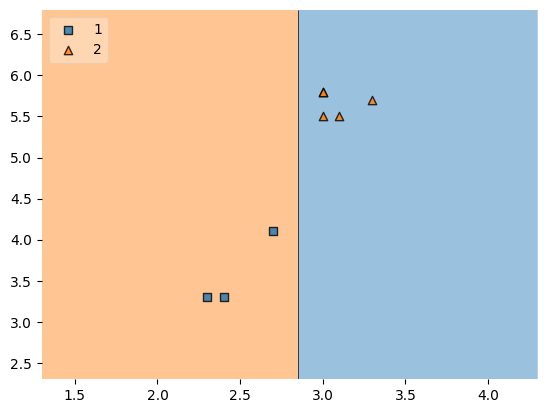

In [76]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [77]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [78]:
df_test

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
91,3.0,4.6,1
77,3.0,5.0,1
62,2.2,4.0,1
145,3.0,5.2,2


In [79]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

NameError: name 'np' is not defined

# Pasting

In [80]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
93,2.3,3.3,1
116,3.0,5.5,2
67,2.7,4.1,1
65,3.1,4.4,1
76,2.8,4.8,1
104,3.0,5.8,2
144,3.3,5.7,2
137,3.1,5.5,2
148,3.4,5.4,2
57,2.4,3.3,1


In [81]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
148,3.4,5.4,2
65,3.1,4.4,1
137,3.1,5.5,2
67,2.7,4.1,1
57,2.4,3.3,1
76,2.8,4.8,1
116,3.0,5.5,2
144,3.3,5.7,2


# Random Subspaces

In [87]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [88]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
29,30,4.7,3.2,1.6,0.2,Iris-setosa
104,105,6.5,3.0,5.8,2.2,Iris-virginica
5,6,5.4,3.9,1.7,0.4,Iris-setosa
135,136,7.7,3.0,6.1,2.3,Iris-virginica
9,10,4.9,3.1,1.5,0.1,Iris-setosa
10,11,5.4,3.7,1.5,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
100,101,6.3,3.3,6.0,2.5,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica
31,32,5.4,3.4,1.5,0.4,Iris-setosa


In [89]:
df1.sample(2,replace=True,axis=1)

,PetalLengthCm,PetalLengthCm
29,1.6,1.6
104,5.8,5.8
5,1.7,1.7
135,6.1,6.1
9,1.5,1.5
10,1.5,1.5
3,1.5,1.5
100,6.0,6.0
103,5.6,5.6
31,1.5,1.5


# Random Patches

In [90]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
29,30,4.7,3.2,1.6,0.2,Iris-setosa
104,105,6.5,3.0,5.8,2.2,Iris-virginica
5,6,5.4,3.9,1.7,0.4,Iris-setosa
135,136,7.7,3.0,6.1,2.3,Iris-virginica
9,10,4.9,3.1,1.5,0.1,Iris-setosa
10,11,5.4,3.7,1.5,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
100,101,6.3,3.3,6.0,2.5,Iris-virginica
103,104,6.3,2.9,5.6,1.8,Iris-virginica
31,32,5.4,3.4,1.5,0.4,Iris-setosa


In [91]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,Species,SepalWidthCm
103,Iris-virginica,2.9
100,Iris-virginica,3.3
135,Iris-virginica,3.0
135,Iris-virginica,3.0
31,Iris-setosa,3.4
29,Iris-setosa,3.2
5,Iris-setosa,3.9
31,Iris-setosa,3.4
